In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import re


In [18]:
BASE_ROOT = Path.home() / "Escritorio" / "Proyecto_FAERS"
quarters = [
    "Q1/data_processed/q1_2025_sample100k", 
    "Q2/data_processed/q2_2025_sample100k", 
    "Q3/data_processed/q3_2025_sample100k", 
    "Q4/data_processed/q4_2025_sample100k"
]

def find_one_csv(qdir: Path, pattern_list):
    for pat in pattern_list:
        hits = list(qdir.glob(pat))
        if hits:
            return hits[0]
    return None

def read_csv_robust(fp: Path):
    return pd.read_csv(fp, low_memory=False, encoding="utf-8-sig")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .map(lambda c: str(c).replace("\ufeff", "").strip().lower())
    )
    return df

In [19]:
def clean_text_key(s: pd.Series) -> pd.Series:
    # normalización ligera para llaves de texto
    s = s.astype(str).str.upper().str.strip()
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.replace(r"[^A-Z0-9/+\-().,]", "", regex=True)
    s = s.replace({"NAN": np.nan, "NONE": np.nan, "": np.nan})
    return s

all_pairs = []
all_reports = []

for q in quarters:
    qdir = BASE_ROOT / q
    fp_drugs = find_one_csv(qdir, ["*drugs*.csv"])
    fp_reac = find_one_csv(qdir, ["*reactions*.csv"])
    fp_rep = find_one_csv(qdir, ["*reports*.csv"])

    if not (fp_drugs and fp_reac and fp_rep):
        print(f"[WARN] Faltan archivos en {qdir}")
        print("drugs:", fp_drugs)
        print("reactions:", fp_reac)
        print("reports:", fp_rep)
        continue

    print(f"\n=== {q} ===")
    print("drugs     :", fp_drugs.name)
    print("reactions :", fp_reac.name)
    print("reports   :", fp_rep.name)

    # Carga CSV
    d = read_csv_robust(fp_drugs)
    r = read_csv_robust(fp_reac)
    rep = read_csv_robust(fp_rep)

    # Normalizar nombres de columnas
    d = normalize_columns(d)
    r = normalize_columns(r)
    rep = normalize_columns(rep)

    # DEBUG útil: ver columnas reales
    print("drugs cols:", list(d.columns))
    print("reac  cols:", list(r.columns))
    print("rep   cols:", list(rep.columns))

    # Validar columnas mínimas
    if "safetyreportid" not in d.columns:
        raise ValueError(f"{q}: drugs no tiene 'safetyreportid'")
    if "safetyreportid" not in r.columns:
        raise ValueError(f"{q}: reactions no tiene 'safetyreportid'")
    if "reaction_pt" not in r.columns:
        raise ValueError(f"{q}: reactions no tiene 'reaction_pt'")
    if "safetyreportid" not in rep.columns:
        raise ValueError(f"{q}: reports no tiene 'safetyreportid'")

    # Crear drug_key si no existe
    if "drug_key" not in d.columns:
        print(f" [INFO] {q}: 'drug_key' no existe; se construirá.")
        if "activesubstancename" in d.columns:
            d["drug_key"] = clean_text_key(d["activesubstancename"])
            source_used = "activesubstancename"
        elif "medicinalproduct" in d.columns:
            d["drug_key"] = clean_text_key(d["medicinalproduct"])
            source_used = "medicinalproduct"
        else:
            raise ValueError(
                f"{q}: drugs no tiene 'drug_key' ni columnas para construirlo\n"
                f" (activesubstancename/medicinalproduct)."
            )
        print(f" [INFO] {q}: drug_key construido desde '{source_used}'")
    else:
        d["drug_key"] = clean_text_key(d["drug_key"])

    # Limpieza reaction_pt
    r["reaction_pt"] = clean_text_key(r["reaction_pt"])

    # Mantener columnas útiles
    keep_d = ["safetyreportid", "drug_key"]
    for c in ["drugcharacterization", "medicinalproduct", "activesubstancename"]:
        if c in d.columns:
            keep_d.append(c)
    d = d[keep_d].copy()

    keep_r = ["safetyreportid", "reaction_pt"]
    if "reaction_meddra_version_pt" in r.columns:
        keep_r.append("reaction_meddra_version_pt")
    r = r[keep_r].copy()

    keep_rep = ["safetyreportid"]
    for c in ["occurcountry", "receiptdate"]:
        if c in rep.columns:
            keep_rep.append(c)
    rep = rep[keep_rep].copy()

    # Tipos
    for x in [d, r, rep]:
        x["safetyreportid"] = pd.to_numeric(x["safetyreportid"], errors="coerce")
        x.dropna(subset=["safetyreportid"], inplace=True)

    if "drugcharacterization" in d.columns:
        d["drugcharacterization"] = pd.to_numeric(d["drugcharacterization"], errors="coerce")

    # Quitar vacíos en llaves
    d = d.dropna(subset=["drug_key"])
    r = r.dropna(subset=["reaction_pt"])

    # Deduplicar bases antes del merge (reduce explosión artificial)
    d = d.drop_duplicates()
    r = r.drop_duplicates()
    rep = rep.drop_duplicates(subset=["safetyreportid"])

    # Merge drugs x reactions por safetyreportid (genera pares)
    pairs_q = d.merge(r, on="safetyreportid", how="inner")
    pairs_q["quarter"] = q

    # Enriquecer con reports (metadatos)
    pairs_q = pairs_q.merge(rep, on="safetyreportid", how="left")

    all_pairs.append(pairs_q)
    all_reports.append(rep.assign(quarter=q))

    print("pairs_q shape:", pairs_q.shape)
    print("reports_q shape:", rep.shape)
    print("drug_key nulos:", pairs_q["drug_key"].isna().sum(), "| reaction_pt nulos:", pairs_q["reaction_pt"].isna().sum())

if not all_pairs:
    raise ValueError("No se pudo construir ningún trimestre.")

pairs = pd.concat(all_pairs, ignore_index=True)
reports_all = pd.concat(all_reports, ignore_index=True)

print("\n=== TOTAL ===")
print("pairs shape:", pairs.shape)
print("columns:", list(pairs.columns))
print("quarters:\n", pairs["quarter"].value_counts(dropna=False))
pairs.head()


=== Q1/data_processed/q1_2025_sample100k ===
drugs     : q1_drugs_100k.csv
reactions : q1_reactions_100k.csv
reports   : q1_reports_100k.csv
drugs cols: ['safetyreportid', 'medicinalproduct', 'drugcharacterization', 'activesubstancename']
reac  cols: ['safetyreportid', 'reaction_pt', 'reaction_meddra_version_pt']
rep   cols: ['safetyreportid', 'occurcountry', 'receiptdate']
 [INFO] Q1/data_processed/q1_2025_sample100k: 'drug_key' no existe; se construirá.
 [INFO] Q1/data_processed/q1_2025_sample100k: drug_key construido desde 'activesubstancename'
pairs_q shape: (2994020, 10)
reports_q shape: (100000, 3)
drug_key nulos: 0 | reaction_pt nulos: 0

=== Q2/data_processed/q2_2025_sample100k ===
drugs     : q2_drugs_100k.csv
reactions : q2_reactions_100k.csv
reports   : q2_reports_100k.csv
drugs cols: ['safetyreportid', 'medicinalproduct', 'drugcharacterization', 'activesubstancename']
reac  cols: ['safetyreportid', 'reaction_pt', 'reaction_meddra_version_pt']
rep   cols: ['safetyreportid',

,safetyreportid,drug_key,drugcharacterization,medicinalproduct,activesubstancename,reaction_pt,reaction_meddra_version_pt,quarter,occurcountry,receiptdate
0,24795582,BUDESONIDEFORMOTEROLFUMARATEDIHYDRATE,1.0,SYMBICORT,BUDESONIDE\FORMOTEROL FUMARATE DIHYDRATE,ASTHMA,27.1,Q1/data_processed/q1_2025_sample100k,US,20250101
1,24795583,DUPILUMAB,1.0,DUPIXENT,DUPILUMAB,NASALPOLYPS,27.1,Q1/data_processed/q1_2025_sample100k,US,20250101
2,24795583,DUPILUMAB,1.0,DUPIXENT,DUPILUMAB,CONDITIONAGGRAVATED,27.1,Q1/data_processed/q1_2025_sample100k,US,20250101
3,24795583,DUPILUMAB,1.0,DUPIXENT,DUPILUMAB,INAPPROPRIATESCHEDULEOFPRODUCTADMINISTRATION,27.1,Q1/data_processed/q1_2025_sample100k,US,20250101
4,24795584,ROSUVASTATINCALCIUM,1.0,CRESTOR,ROSUVASTATIN CALCIUM,DRUGINTERACTION,27.1,Q1/data_processed/q1_2025_sample100k,US,20250101


In [20]:
#esta vez coincide perfectamnete , todo bien 
#los pares nos salen iguales 
#Hasta aqui lo que se hace es una base de datos gigante por ais decirlo 11570,960 filas y 10 columnas 
#seguimos con el mapeo

In [21]:
# 1=PS, 2=SS, 3=C, 4=I, 5=O (ocasional)
role_map = {
    1: "PS",
    2: "SS",
    3: "C",
    4: "I",
    5: "O"
}

pairs["drugcharacterization"] = pd.to_numeric(pairs["drugcharacterization"], errors="coerce")
pairs["role_cod"] = pairs["drugcharacterization"].map(role_map).fillna("UNK")

print("Distribución de roles:")
print(pairs["role_cod"].value_counts(dropna=False).rename_axis("role_cod").reset_index(name="n"))

print("\nDistribución de drugcharacterization cruda:")
pairs["drugcharacterization"].value_counts(dropna=False).sort_index()

Distribución de roles:
  role_cod        n
0       PS  6388933
1       SS  5128646
2        C    53255
3        I      121
4      UNK        5

Distribución de drugcharacterization cruda:


drugcharacterization
1.0    6388933
2.0    5128646
3.0      53255
4.0        121
NaN          5
Name: count, dtype: int64

In [22]:
#aqui lo que se puede ver es que muchos son PS

In [23]:
#AUDITORIA
print("=== Auditoría de pairs ===")
print("Filas totales:", len(pairs))
print("Reportes únicos:", pairs["safetyreportid"].nunique())
print("Drugs únicos (drug_key):", pairs["drug_key"].nunique())
print("Reacciones únicas (PT):", pairs["reaction_pt"].nunique())
print("Trimestres:", pairs["quarter"].nunique())

print("\nTop 10 países (occurcountry):")
display(pairs["occurcountry"].astype(str).value_counts(dropna=False).head(10))

print("\nTop 10 drug_key:")
display(pairs["drug_key"].value_counts().head(10))

print("\nTop 10 reaction_pt:")
display(pairs["reaction_pt"].value_counts().head(10))

# Confirmar limitación metodológica actual
print("\n[INFO] Nivel de análisis actual: safetyreportid (reporte)")
print("[INFO] No hay caseid/version en estos archivos; no aplica deduplicación canónica FAERS por caso todavía.")

=== Auditoría de pairs ===
Filas totales: 11570960
Reportes únicos: 390140
Drugs únicos (drug_key): 6710
Reacciones únicas (PT): 13097
Trimestres: 4

Top 10 países (occurcountry):


occurcountry
CA     6144121
US     3294210
EU      466857
NaN     281368
GB      258296
JP      185573
DE      133609
CN       97834
FR       93948
AU       60113
Name: count, dtype: int64


Top 10 drug_key:


drug_key
ACETAMINOPHEN              186848
PREDNISONE                 140187
CHOLECALCIFEROL            118188
ADALIMUMAB                 114430
DUPILUMAB                  104318
CETIRIZINEHYDROCHLORIDE    103104
INFLIXIMAB                  97467
LEFLUNOMIDE                 96952
RITUXIMAB                   91162
METHOTREXATE                88926
Name: count, dtype: int64


Top 10 reaction_pt:


reaction_pt
OFFLABELUSE        168454
FATIGUE            134550
DRUGINEFFECTIVE    129021
NAUSEA             116422
HEADACHE           110655
PAIN               105876
DIARRHOEA          102874
DYSPNOEA            95181
VOMITING            85925
ARTHRALGIA          80241
Name: count, dtype: int64


[INFO] Nivel de análisis actual: safetyreportid (reporte)
[INFO] No hay caseid/version en estos archivos; no aplica deduplicación canónica FAERS por caso todavía.


In [24]:
#aqui es bueno decir que no contamos con in id clinico pero se hace con base al report id , igual podemos ver que Canadá es el pais
#con mayor reportes y ademas podemos darnos cuenta que el primer efecto adverso no es un sintoma medico sino que es por uso fuera de indicacion
#esto nos dice que hay que quitar los admin-like

In [30]:
# Estandarización final de texto
pairs["drug_key"] = pairs["drug_key"].astype(str).str.strip().str.upper() #quita espacioy pone en mayúsculas
pairs["reaction_pt"] = pairs["reaction_pt"].astype(str).str.strip().str.upper() 

# Subconjuntos por rol sin copias por kernel
pairs_ps = pairs[pairs["role_cod"].eq("PS")] # Crea un grupo solo con los (PS)
pairs_ps_ss = pairs[pairs["role_cod"].isin(["PS", "SS"])]
pairs_allroles = pairs 

print("=== Tamaños por esquema ===")
print("PS    :", len(pairs_ps)) #total de filas (pares) en el grupo PS
print("PS+SS :", len(pairs_ps_ss)) 
print("ALL   :", len(pairs_allroles)) 

print("\nReportes únicos por esquema:")
print("PS    :", pairs_ps["safetyreportid"].nunique()) # Cuenta cuántos IDs de reporte únicos hay en PS
print("PS+SS :", pairs_ps_ss["safetyreportid"].nunique())
print("ALL   :", pairs_allroles["safetyreportid"].nunique())

pairs_main = pairs_ps if len(pairs_ps) > 0 else pairs_allroles #PS como tabla principal (si tiene datos); si falla, usa ALL
MAIN_SCHEME = "PS" if len(pairs_ps) > 0 else "ALL" 
print("\nAnálisis principal:", MAIN_SCHEME)

=== Tamaños por esquema ===
PS    : 6388933
PS+SS : 11517579
ALL   : 11570960

Reportes únicos por esquema:
PS    : 388573
PS+SS : 389231
ALL   : 390140

Análisis principal: PS


In [26]:
#aqui igual por esquema lo que obtenemos es que tenemos 6388933 pares de farmaco-reaccion en ps y que al añadir un secundo sospechosos pues aumenta bastante 
# y cuando vemos los reportes unicos es todo lo contrario al ver las filas de Ps y sumarles las del segundo sospechosos podemos ver que no aumneta drasticamente y al añadir todos tampoco da un brinco sumamente importante

In [27]:
#ASI que podemos hacer un analisis principlas en PS unicamente dejando los demas como analisis de sensibilidad unicamnete 

In [28]:
MIN_N11 = 5 #mínimo de reportes para considerar una señal válida
HALDANE_EPS = 0.5 

def build_signal_table_report_level(df_pairs: pd.DataFrame,
                                    unit_id: str = "safetyreportid",
                                    drug_col: str = "drug_key",
                                    reac_col: str = "reaction_pt",
                                    min_n11: int = 5,
                                    eps: float = 0.5) -> pd.DataFrame:
    """
    Construye tabla de señales (D,A) a nivel reporte (safetyreportid),
    con conteos 2x2, ROR, PRR e IC95%.
    """
    df = df_pairs.copy() # Crea una copia para no alterarbase original
    df = df.dropna(subset=[unit_id, drug_col, reac_col]).copy() #elimina filas a las que les falte el ID, fármaco o reacción

    # Deduplicación por unidad (reporte)
    df4 = df.drop_duplicates([unit_id, drug_col, reac_col])  #deja solo combinaciones únicas de Reporte-Fármaco-Reacción
    dfD = df.drop_duplicates([unit_id, drug_col])            #únicas de Reporte-Fármaco
    dfA = df.drop_duplicates([unit_id, reac_col])            #unicas de Reporte-Reacción

    N = df[unit_id].nunique() #número de reportes únicos

    # Conteos
    n11 = (df4.groupby([drug_col, reac_col]).size().rename("n11").reset_index()) # Cuenta cuántas veces aparecen juntos el fármaco Y la reacción
    n1dot = (dfD.groupby(drug_col).size().rename("n1dot").reset_index()) 
    ndot1 = (dfA.groupby(reac_col).size().rename("ndot1").reset_index()) 

    # Une todos los conteos en una tabla llamada sig
    sig = (n11.merge(n1dot, on=drug_col, how="left")
              .merge(ndot1, on=reac_col, how="left"))

    sig["N"] = float(N) #agrega el total de reportes a la tabla
    sig["n10"] = sig["n1dot"] - sig["n11"] #b
    sig["n01"] = sig["ndot1"] - sig["n11"] #c
    sig["n00"] = sig["N"] - (sig["n11"] + sig["n10"] + sig["n01"]) #d

    #formato numérico  
    for c in ["n11","n10","n01","n00","n1dot","ndot1","N"]:
        sig[c] = pd.to_numeric(sig[c], errors="coerce").astype(float)

    sig = sig[(sig[["n11","n10","n01","n00"]] >= 0).all(axis=1)].copy() #borra por seguridad cualquier conteo negativo
    
#vectoriza para rapido
    a = sig["n11"].to_numpy()
    b = sig["n10"].to_numpy()
    c = sig["n01"].to_numpy()
    d = sig["n00"].to_numpy()

    a2 = np.where(a == 0, a + eps, a) 
    b2 = np.where(b == 0, b + eps, b) 
    c2 = np.where(c == 0, c + eps, c) 
    d2 = np.where(d == 0, d + eps, d) 


    # ROR + IC95%
    sig["ROR"] = (a2 * d2) / (b2 * c2) 
    sig["logROR"] = np.log(sig["ROR"]) #saca el logaritmo 
    sig["SE_logROR"] = np.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2) #Error Estándar 
    sig["ROR_L95"] = np.exp(sig["logROR"] - 1.96 * sig["SE_logROR"]) #Límite Inferior al 95%
    sig["ROR_U95"] = np.exp(sig["logROR"] + 1.96 * sig["SE_logROR"]) #Límite Superior al 95%

    # PRR
    sig["PRR"] = (a2 / (a2 + b2)) / (c2 / (c2 + d2)) 

    # Señales
    sig["signal_ror"] = (sig["n11"] >= min_n11) & (sig["ROR_L95"] > 1) # Activa si hay mas 5 casos Y el riesgo mínimo es > 1
    sig["signal_prr"] = (sig["n11"] >= min_n11) & (sig["PRR"] >= 2) #si hay casos Y la proporción es >= 2
    sig["signal_both"] = sig["signal_ror"] & sig["signal_prr"] #si cumple ambas condiciones estadísticas

    # Ranking exploratorio
    sig["priority_score"] = np.log(np.clip(sig["ROR_L95"], 1e-12, None)) * np.log1p(sig["n11"]) #un puntaje balanceando la fuerza del riesgo y el volumen de casos

    sig["unit_id_used"] = unit_id # Registra qué columna se usó para el conteo base
    
    #Tabla arrojando las señales más críticas hasta arriba
    return sig.sort_values(["signal_ror", "ROR_L95", "n11"], ascending=[False, False, False]).reset_index(drop=True)

In [31]:
# Construcción de señales para los tres ps, ps+ss, y todas
#aqui se me reinicio el kernel por lo que opte usar gc
import gc # Librería para limpiar la memoria RAM

sig_ps = build_signal_table_report_level(pairs_ps, min_n11=MIN_N11, eps=HALDANE_EPS) if len(pairs_ps) else pd.DataFrame() # Calcula las señales solo para Sospechosos Primarios 
gc.collect()

sig_ps_ss = build_signal_table_report_level(pairs_ps_ss, min_n11=MIN_N11, eps=HALDANE_EPS) if len(pairs_ps_ss) else pd.DataFrame() 
gc.collect()

sig_all = build_signal_table_report_level(pairs_allroles, min_n11=MIN_N11, eps=HALDANE_EPS)
gc.collect()

# Crea una tabla comp (DataFrame) 
summary_signals = pd.DataFrame([
    {
        "scheme": "PS", #Etiqueta para la fila
        "N_reports": int(pairs_ps["safetyreportid"].nunique()) if len(pairs_ps) else 0, #cuenta reportes únicos analizados en PS
        "pairs_total": int(len(sig_ps)) if len(sig_ps) else 0, #total fármaco-reacción evaluadas
        "signal_ror_count": int(sig_ps["signal_ror"].sum()) if len(sig_ps) else 0, #suma cuántas alertas ROR se detectaron
        "signal_prr_count": int(sig_ps["signal_prr"].sum()) if len(sig_ps) else 0, 
        "signal_both_count": int(sig_ps["signal_both"].sum()) if len(sig_ps) else 0, #ROR y PRR al mismo tiempo
    },
    {
        "scheme": "PS+SS", #fila del esquema Primarios + Secundarios
        "N_reports": int(pairs_ps_ss["safetyreportid"].nunique()) if len(pairs_ps_ss) else 0, #reportes únicos analizados en PS+SS
        "pairs_total": int(len(sig_ps_ss)) if len(sig_ps_ss) else 0, 
        "signal_ror_count": int(sig_ps_ss["signal_ror"].sum()) if len(sig_ps_ss) else 0, # Total ROR detectadas al sumar secundarios
        "signal_prr_count": int(sig_ps_ss["signal_prr"].sum()) if len(sig_ps_ss) else 0, 
        "signal_both_count": int(sig_ps_ss["signal_both"].sum()) if len(sig_ps_ss) else 0, 
    },
    {
        "scheme": "ALL", 
        "N_reports": int(pairs_allroles["safetyreportid"].nunique()), 
        "pairs_total": int(len(sig_all)), #commbinaciones totalesen toda la base 
        "signal_ror_count": int(sig_all["signal_ror"].sum()),
        "signal_prr_count": int(sig_all["signal_prr"].sum()), 
        "signal_both_count": int(sig_all["signal_both"].sum()), #total de señalesglobales
    }])

print("=== Resumen de señales ===") 
summary_signals


=== Resumen de señales ===


,scheme,N_reports,pairs_total,signal_ror_count,signal_prr_count,signal_both_count
0,PS,388573,702312,139587,138130,137038
1,PS+SS,389231,1443388,229458,223060,219198
2,ALL,390140,1448215,230930,224474,220611


In [32]:
#Aqui lo que podemos ver es que se respalda la validacion de por que es esencial utilizar solo PS 
#al fijarnos en N_reporte podemos ver en PS unicamente 388573 y al añadirlo los secundarios aumenta muy poco y añadiendo los demas igual

#el usar unicamente PS no indica que perderemos informacion.

In [33]:
#TOP SEÑALES DE ANALISIS PRINCIPAL
sig_main = sig_ps if len(sig_ps) else sig_all #usa Sospechosos Primarios como tabla principal; si está vacía entonces TODOS

top_ror = (sig_main[sig_main["signal_ror"]] # Filtra solo las filas que sí son una señal estadística (ROR_L95 > 1 y n11 >= 5)
           .sort_values(["ROR_L95", "n11"], ascending=[False, False]) #de mayor a menor basándose en el riesgo y luego por frecuencia
           [["drug_key","reaction_pt","n11","ROR","ROR_L95","ROR_U95","PRR","priority_score"]] # Selecciona solo estas columnas 
           .head(30))

top_score = (sig_main[sig_main["signal_ror"]] # Vuelve a filtrar solo las señales reales 
             .sort_values(["priority_score", "n11"], ascending=[False, False]) #de mayor a menor, balanceando riesgo y volumen de casos
             [["drug_key","reaction_pt","n11","ROR","ROR_L95","PRR","priority_score"]] #no incluye ROR_U95)
             .head(30)) 
print("=== Top señales por ROR_L95 ===") 
top_ror

=== Top señales por ROR_L95 ===


,drug_key,reaction_pt,n11,ROR,ROR_L95,ROR_U95,PRR,priority_score
0,MENTHOL,EXPOSURETOCHEMICALPOLLUTION,181.0,5.021005e+05,209727.423368,1.202060e+06,49961.145700,63.767629
1,DIACEREIN,BRAINSCANABNORMAL,7.0,5.439910e+06,168478.433763,1.756463e+08,362661.600000,25.025170
2,TECHNETIUMTC-99MSODIUMPERTECHNETATE,SCANMYOCARDIALPERFUSIONABNORMAL,8.0,1.554248e+06,127769.207008,1.890664e+07,172695.111111,25.834924
3,COPPER,FOREIGNBODYINREPRODUCTIVETRACT,561.0,7.373175e+05,103332.688051,5.261038e+06,254099.575935,73.101678
4,PREDNAZOLINE,BRAINSCANABNORMAL,6.0,2.331390e+06,94969.120701,5.723312e+07,179338.615385,22.302674
5,DIACEREIN,CEREBRALARTERYTHROMBOSIS,7.0,1.813294e+06,82984.948711,3.962207e+07,120887.200000,23.552617
6,GUANIDINE,AMYLOIDARTHROPATHY,5.0,1.942830e+06,77578.535066,4.865506e+07,555095.000000,20.173502
7,HEXACHLOROPHENE,VASCULARMALFORMATION,5.0,1.942830e+06,77578.535066,4.865506e+07,176621.818182,20.173502
8,PENFLURIDOL,PAROXYSMALPERCEPTUALALTERATION,5.0,1.942830e+06,77578.535066,4.865506e+07,176621.818182,20.173502
9,SULFAGUANIDINE,AMYLOIDARTHROPATHY,5.0,1.942830e+06,77578.535066,4.865506e+07,555095.000000,20.173502


In [34]:
#ahora el score 
print("=== Top señales por priority_score ===")
top_score

=== Top señales por priority_score ===


,drug_key,reaction_pt,n11,ROR,ROR_L95,PRR,priority_score
3,COPPER,FOREIGNBODYINREPRODUCTIVETRACT,561.0,737317.545763,103332.688051,254099.575935,73.101678
26,COPPER,REPRODUCTIVECOMPLICATIONASSOCIATEDWITHDEVICE,437.0,808746.200477,50419.957872,395870.438084,65.859132
0,MENTHOL,EXPOSURETOCHEMICALPOLLUTION,181.0,502100.464286,209727.423368,49961.145700,63.767629
233,COPPER,COMPLICATIONOFDEVICEREMOVAL,635.0,17965.328054,13412.732576,4638.986565,61.349947
624,MEDROXYPROGESTERONEACETATE,MENINGIOMA,397.0,8509.643990,6460.171586,3164.815408,52.521605
1301,VEDOLIZUMAB,THERAPEUTICREACTIONTIMEDECREASED,347.0,12943.708179,3223.344630,12124.459777,47.275115
611,ETHINYLESTRADIOLNORELGESTROMIN,PRODUCTADHESIONISSUE,202.0,12987.360531,6632.357478,554.920591,46.754702
2212,ESKETAMINE,DISSOCIATION,470.0,2327.363020,1810.413723,1604.221076,46.169503
169,ETONOGESTREL,PREGNANCYWITHIMPLANTCONTRACEPTIVE,114.0,264156.035821,16387.918077,197087.719376,46.046243
1167,ALBUTEROLSULFATE,DEVICEDEPOSITISSUE,253.0,8693.832132,3584.020730,7814.117520,45.318876


In [35]:
#Podemos darnos cuenta como en el analisis de severidad que el diu de cobre sale en primer lugar, por que no hemos filtrado los admin-like


In [36]:
#SIN ADMINISTRATIVOS Y OPERACIONALES

In [45]:
muestras_label = sig_main[sig_main["reaction_pt"].str.contains("LABEL", na=False)]["reaction_pt"].value_counts().head(10)
print(muestras_label)

print("\n--- Detectando variaciones de PRODUCT")
muestras_product = sig_main[sig_main["reaction_pt"].str.contains("PRODUCT", na=False)]["reaction_pt"].value_counts().head(10)
print(muestras_product)

reaction_pt
OFFLABELUSE                                    2788
PRODUCTLABELCONFUSION                           326
LABELLEDDRUG-DRUGINTERACTIONISSUE               197
PRODUCTLABELISSUE                               139
LABELLEDDRUG-DRUGINTERACTIONMEDICATIONERROR      79
PHYSICALPRODUCTLABELISSUE                        44
LABELLEDDRUG-FOODINTERACTIONMEDICATIONERROR      33
LABELLEDDRUG-FOODINTERACTIONISSUE                13
GLABELLARREFLEXABNORMAL                          11
OFFLABELUSEOFDEVICE                               6
Name: count, dtype: int64

--- Detectando variaciones de PRODUCT
reaction_pt
PRODUCTUSEINUNAPPROVEDINDICATION                1794
PRODUCTUSEISSUE                                 1377
THERAPEUTICPRODUCTEFFECTINCOMPLETE              1290
PRODUCTDOSEOMISSIONISSUE                        1258
INAPPROPRIATESCHEDULEOFPRODUCTADMINISTRATION    1201
INTENTIONALPRODUCTMISUSE                        1072
INTENTIONALPRODUCTUSEISSUE                      1030
INCORRECTROUTEOFPROD

In [46]:
#lista negra
admin_patterns = [
    "OFF LABEL USE",
    "DRUG INEFFECTIVE",
    "PRODUCT USE IN UNAPPROVED INDICATION",
    "PRODUCT USE ISSUE",
    "INTENTIONAL PRODUCT USE ISSUE",
    "PRODUCT USE COMPLAINT",
    "DRUG INEFFECTIVE FOR UNAPPROVED INDICATION",
    "THERAPEUTIC PRODUCT EFFECT INCOMPLETE",
    "THERAPEUTIC PRODUCT EFFECT DECREASED",
    "THERAPEUTIC RESPONSE DECREASED",
    "THERAPEUTIC RESPONSE SHORTENED",
    "PRODUCT DOSE OMISSION ISSUE",
    "INAPPROPRIATE SCHEDULE OF PRODUCT ADMINISTRATION",
    "CONTRAINDICATED PRODUCT ADMINISTERED",
    "INTENTIONAL PRODUCT MISUSE",
    "MEDICATION ERROR",
    "INCORRECT ROUTE OF PRODUCT ADMINISTRATION",
    "INCORRECT PRODUCT ADMINISTRATION DURATION",
    "INTENTIONAL DOSE OMISSION",
    "PRODUCT DOSE OMISSION IN ERROR",
    "WRONG TECHNIQUE IN PRODUCT USAGE PROCESS",
    "PRODUCT ADMINISTRATION INTERRUPTED",
    "PRODUCT QUALITY ISSUE",
    "PRODUCT LABEL CONFUSION",
    "PRODUCT DISTRIBUTION ISSUE",
    "DEVICE ISSUE",
]

#Quitamos los espacios (.replace(" ", "")) de nuestra lista negra 
admin_set = {x.strip().upper().replace(" ", "") for x in admin_patterns} 

# Marcar PTs administrativos / operacionales
# Quitamos también los espacios de la columna para que coincidan perfectamente
sig_main["reaction_pt"] = sig_main["reaction_pt"].astype(str).str.strip().str.upper().str.replace(" ", "")
sig_main["is_admin_like"] = sig_main["reaction_pt"].isin(admin_set) # Etiqueta con True si la reacción pertenece a la lista

# Vistas de análisis
sig_main_allpts = sig_main.copy() 
sig_main_clinical = sig_main.loc[~sig_main["is_admin_like"]].copy() # Filtra y guarda solo los síntomas médicos reales
sig_main_admin = sig_main.loc[sig_main["is_admin_like"]].copy() # Filtra y guarda únicamente los problemas técnicos

print("=== Resumen PTs admin-like ===")
print("Total pares señalables en sig_main:", len(sig_main)) 
print("Admin-like PTs:", int(sig_main["is_admin_like"].sum())) 
print("No admin-like (clínicos):", int((~sig_main["is_admin_like"]).sum())) 

print("\nSeñales ROR positivas:")
print("ALL:", int(sig_main["signal_ror"].sum())) 
print("Clinical:", int(sig_main_clinical["signal_ror"].sum())) 
print("Admin-like:", int(sig_main_admin["signal_ror"].sum())) 

print("\nTop admin-like por n11:")
print(
    sig_main_admin.sort_values(["signal_ror", "n11"], ascending=[False, False]) 
    [["drug_key", "reaction_pt", "n11", "ROR_L95", "PRR", "signal_ror", "signal_prr"]] 
    .head(20) 
)

=== Resumen PTs admin-like ===
Total pares señalables en sig_main: 702312
Admin-like PTs: 23350
No admin-like (clínicos): 678962

Señales ROR positivas:
ALL: 139587
Clinical: 132438
Admin-like: 7149

Top admin-like por n11:
                    drug_key                                   reaction_pt  \
92841              DUPILUMAB              PRODUCTUSEINUNAPPROVEDINDICATION   
115647             DUPILUMAB  INAPPROPRIATESCHEDULEOFPRODUCTADMINISTRATION   
94863              RITUXIMAB                                   OFFLABELUSE   
96718            VEDOLIZUMAB                                   OFFLABELUSE   
89630             INFLIXIMAB                                   OFFLABELUSE   
107376            PREDNISONE                                   OFFLABELUSE   
89376        INSULINGLARGINE                                   OFFLABELUSE   
107285            PREDNISONE                               DRUGINEFFECTIVE   
31900       ALBUTEROLSULFATE           WRONGTECHNIQUEINPRODUCTUSAGEPROCESS

In [47]:
#Vemos combinaciones únicas de Fármaco + Reacción que sobrevivieron. Luego vemos cuántos casos eran puro ruido administrativo
#y cuántos son verdaderas señales clínicas. 
#Tambien vemos las señales estadísticas positivas (donde el $ROR > 1) para que veamos cuáles de esas alertas 
#provenían derrores de uso y cuáles son médicas, en las que realmente vale la pena ver mas.
#Por último tenemos a falsos culpables mostrando las 20 alertas administrativas más frecuentes
#como OFFLABELUSE, y eso confirma que logramos toda esa basura antes de que 
#contamine todo

In [48]:
#GRÁFICAS


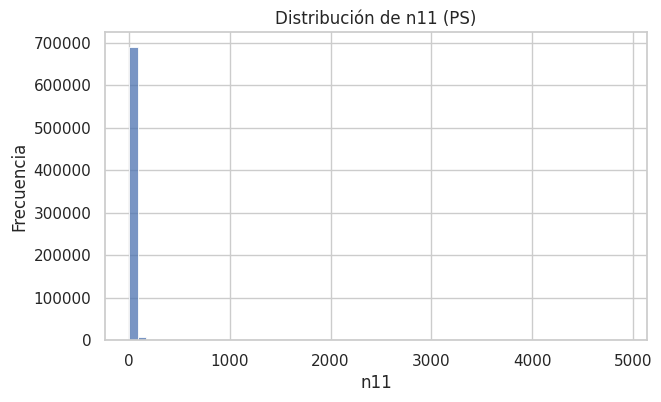

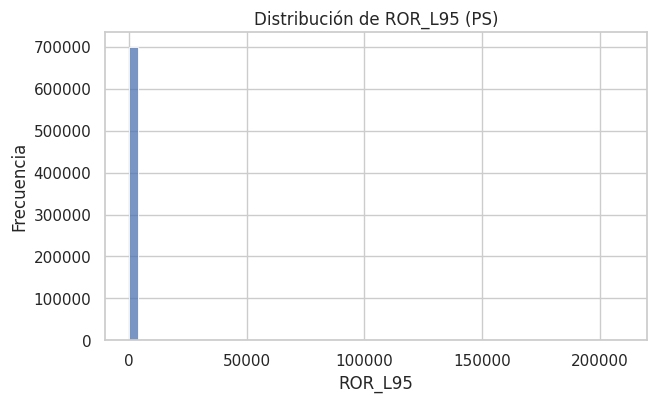

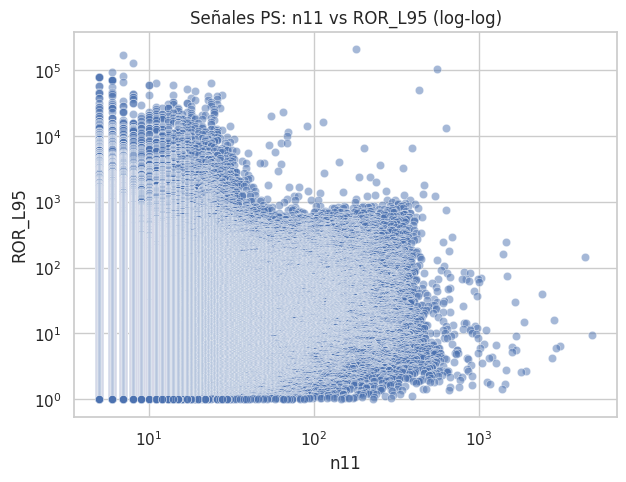

In [55]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Hist n11
plt.figure(figsize=(7,4))
sns.histplot(sig_main["n11"], bins=60)
plt.title(f"Distribución de n11 ({MAIN_SCHEME})")
plt.xlabel("n11")
plt.ylabel("Frecuencia")
plt.show()

# Hist ROR_L95 (recortando inf)
tmp_ror = sig_main["ROR_L95"].replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(7,4))
sns.histplot(tmp_ror, bins=60)
plt.title(f"Distribución de ROR_L95 ({MAIN_SCHEME})")
plt.xlabel("ROR_L95")
plt.ylabel("Frecuencia")
plt.show()

# Scatter señales
tmp = sig_main[sig_main["signal_ror"]].replace([np.inf, -np.inf], np.nan).dropna(subset=["n11", "ROR_L95"])
plt.figure(figsize=(7,5))
sns.scatterplot(data=tmp, x="n11", y="ROR_L95", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title(f"Señales {MAIN_SCHEME}: n11 vs ROR_L95 (log-log)")
plt.xlabel("n11")
plt.ylabel("ROR_L95")
plt.show()

In [56]:
#el histograma de n11 muestra una asimetría: casi todos los pares fármaco-reacción tienenpocos incidentes,
#siendo muy raros los eventos de alta frecuencia.
#Asimismo, el indicador ROR_L95 se concentra en niveles de riesgo bajos y moderados, proyectando una cola alargada
#hacia los extremos. 
#Esta topología es el resultado esperado en el análisis de desproporcionalidad en farmacovigilancia,
#donde abundan las estadísticamente débiles y escasean las señales de 
#riesgo critico

In [63]:
!pip install pyarro


ERROR: Could not find a version that satisfies the requirement pyarro (from versions: none)
ERROR: No matching distribution found for pyarro


In [62]:
OUT_DIR = Path("outputs_faers_report_level")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Iniciando guardado de archivos CSV en:", OUT_DIR.resolve())
print("Guardando tablas base...")
pairs.to_csv(OUT_DIR / "pairs_q1q4_drugs_reactions.csv", index=False)
reports_all.to_csv(OUT_DIR / "reports_q1q4_concat.csv", index=False)

print("Guardando señales por esquema...")
if 'sig_ps' in locals() and not sig_ps.empty:
    sig_ps.to_csv(OUT_DIR / "signals_ps_report_level.csv", index=False)

if 'sig_ps_ss' in locals() and not sig_ps_ss.empty:
    sig_ps_ss.to_csv(OUT_DIR / "signals_ps_ss_report_level.csv", index=False)

if 'sig_all' in locals():
    sig_all.to_csv(OUT_DIR / "signals_allroles_report_level.csv", index=False)

print("Guardando señales positivas y auditoría...")
if 'sig_main' in locals():
    (sig_main[sig_main["signal_ror"]]
     .sort_values(["ROR_L95", "n11"], ascending=[False, False])
     .to_csv(OUT_DIR / f"signals_main_{MAIN_SCHEME.lower()}_ror_positive.csv", index=False))

# Resumen de los esquemas
summary_signals.to_csv(OUT_DIR / "summary_signals_role_schemes.csv", index=False)

# --- Auditoría Final ---
audit = pd.DataFrame([{
    "input_pairs_rows": int(len(pairs)),
    "unique_reports": int(pairs["safetyreportid"].nunique()),
    "unique_drugs": int(pairs["drug_key"].nunique()),
    "unique_reactions": int(pairs["reaction_pt"].nunique()),
    "analysis_level": "safetyreportid",
    "main_scheme": MAIN_SCHEME,
    "main_signal_ror_count": int(sig_main["signal_ror"].sum()),
    "min_n11": MIN_N11,
    "haldane_eps": HALDANE_EPS 
}])

audit.to_csv(OUT_DIR / "audit_summary.csv", index=False)

print("\n¡Todo guardado con éxito en formato CSV!")
print("Archivos generados:")
for fp in sorted(OUT_DIR.glob("*.csv")):
    print("-", fp.name)

Iniciando guardado de archivos CSV en: /home/violeta/Escritorio/Proyecto_FAERS/outputs_faers_report_level
Guardando tablas base...
Guardando señales por esquema...
Guardando señales positivas y auditoría...

¡Todo guardado con éxito en formato CSV!
Archivos generados:
- audit_summary.csv
- pairs_q1q4_drugs_reactions.csv
- reports_q1q4_concat.csv
- signals_allroles_report_level.csv
- signals_main_ps_ror_positive.csv
- signals_ps_report_level.csv
- signals_ps_ss_report_level.csv
- summary_signals_role_schemes.csv
